# Mercado Libre - Product Condition Classification and Price Prediction

## Project Overview
In this project, we act as Senior Data Scientists at Mercado Libre with two main business goals:

1. **Classify product condition** as **new** or **used**.
2. **Predict the product price** based on listing information.

This project combines two predictive analytics tasks:

- **Classification**: detect whether a product is new or used.
- **Regression**: estimate the product price.

The work will follow a structured data science workflow including:
- data loading
- data understanding
- data cleaning
- feature engineering
- modeling
- evaluation
- interpretation of results

## Initial Objective
At this stage, we begin by loading the dataset and performing an initial inspection to understand:
- the available variables
- the structure of the data
- potential missing values
- candidate features for both tasks

In [61]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 200)

# File path
file_path = "MLA_100k_checked_v3.jsonlines"

# Load dataset
df = pd.read_json(file_path, lines=True)

# Basic shape
print("Dataset shape:", df.shape)

Dataset shape: (100000, 45)


## Loading the Dataset

We load the Mercado Libre dataset in `.jsonlines` format using pandas.  
Since each line represents a JSON record, the parameter `lines=True` is required.

The first step is to confirm that the dataset was loaded correctly and to inspect its size in terms of rows and columns.

This is important because the project requirements specify that the dataset must contain at least:

- **1,000 rows**
- **10 columns**

As the shared dataset contains 10,000 rows and 45 columns, it meets the minimum requirements for this assignment.

We expect this dataset to satisfy those conditions comfortably.

## 1. Initial Dataset Inspection

Before building any predictive model, we need to understand the dataset structure.

At this stage, our goals are:
- review the available columns,
- identify data types,
- detect missing values,
- understand which variables may be useful for modeling,
- identify columns that may need to be removed or transformed.

This step is essential because the dataset contains structured, semi-structured, and potentially high-missingness fields.

In [62]:
# Display all column names
df.columns.tolist()

['seller_address',
 'warranty',
 'sub_status',
 'condition',
 'deal_ids',
 'base_price',
 'shipping',
 'non_mercado_pago_payment_methods',
 'seller_id',
 'variations',
 'site_id',
 'listing_type_id',
 'price',
 'attributes',
 'buying_mode',
 'tags',
 'listing_source',
 'parent_item_id',
 'coverage_areas',
 'category_id',
 'descriptions',
 'last_updated',
 'international_delivery_mode',
 'pictures',
 'id',
 'official_store_id',
 'differential_pricing',
 'accepts_mercadopago',
 'original_price',
 'currency_id',
 'thumbnail',
 'title',
 'automatic_relist',
 'date_created',
 'secure_thumbnail',
 'stop_time',
 'status',
 'video_id',
 'catalog_product_id',
 'subtitle',
 'initial_quantity',
 'start_time',
 'permalink',
 'sold_quantity',
 'available_quantity']

Reviewing the column names helps us identify:

- possible target variables,
- candidate predictive features,
- identifiers,
- date fields,
- text variables,
- nested or semi-structured variables.

At first glance, this dataset appears to include both simple variables (e.g., `price`, `condition`) and complex variables (e.g., `shipping`, `attributes`, `pictures`, `seller_address`).

In [63]:
df[df["warranty"].notna()]["warranty"].head(10)

1                            NUESTRA REPUTACION
4                                MI REPUTACION.
5                                            Sí
8                                         1 Ano
12                          VACIOS sin utilizar
16                 Se ve en el dia de la compra
20    100% de acuerdo a descripcion e imagenes.
26                     Sí. Librería a la calle.
27                                           Sí
30                           Mis calificaciones
Name: warranty, dtype: object

In [64]:
# Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 45 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   seller_address                    100000 non-null  object        
 1   warranty                          39104 non-null   object        
 2   sub_status                        100000 non-null  object        
 3   condition                         100000 non-null  object        
 4   deal_ids                          100000 non-null  object        
 5   base_price                        100000 non-null  float64       
 6   shipping                          100000 non-null  object        
 7   non_mercado_pago_payment_methods  100000 non-null  object        
 8   seller_id                         100000 non-null  int64         
 9   variations                        100000 non-null  object        
 10  site_id                          

The `info()` output allows us to inspect:

- each variable's data type,
- non-null counts,
- potential missing values,
- columns stored as generic objects.

This is especially important because object-type columns may represent:
- text,
- categories,
- lists,
- dictionaries,
- or mixed formats.

Those columns cannot always be used directly in machine learning models and may require preprocessing.

In [65]:
# Preview first rows
df.head(5)

,seller_address,warranty,sub_status,condition,deal_ids,base_price,shipping,non_mercado_pago_payment_methods,seller_id,variations,site_id,listing_type_id,price,attributes,buying_mode,tags,listing_source,parent_item_id,coverage_areas,category_id,descriptions,last_updated,international_delivery_mode,pictures,id,official_store_id,differential_pricing,accepts_mercadopago,original_price,currency_id,thumbnail,title,automatic_relist,date_created,secure_thumbnail,stop_time,status,video_id,catalog_product_id,subtitle,initial_quantity,start_time,permalink,sold_quantity,available_quantity
0,"{'country': {'name': 'Argentina', 'id': 'AR'}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}, 'city': {'name': 'San Cristóbal', 'id': 'TUxBQlNBTjkwNTZa'}}",None,[],new,[],80.0,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'not_specified', 'dimensions': None}","[{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Acordar con el comprador', 'id': 'MLAWC', 'type': 'G'}, {'description': 'Efectivo', 'id': 'MLAMO', 'type': ...",8208882349,[],MLA,bronze,80.0,[],buy_it_now,[dragged_bids_and_visits],,MLA6553902747,[],MLA126406,[{'id': 'MLA4695330653-912855983'}],2015-09-05T20:42:58.000Z,none,"[{'size': '500x375', 'secure_url': 'https://a248.e.akamai.net/mla-s1-p.mlstatic.com/5386-MLA4695330653_052013-O.jpg', 'max_size': '1200x900', 'url': 'http://mla-s1-p.mlstatic.com/5386-MLA469533065...",MLA4695330653,NaN,NaN,True,NaN,ARS,http://mla-s1-p.mlstatic.com/5386-MLA4695330653_052013-I.jpg,Auriculares Samsung Originales Manos Libres Cable Usb Oferta,False,2015-09-05T20:42:53.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/5386-MLA4695330653_052013-I.jpg,2015-11-04 20:42:53,active,None,NaN,NaN,1,2015-09-05 20:42:53,http://articulo.mercadolibre.com.ar/MLA4695330653-auriculares-samsung-originales-manos-libres-cable-usb-oferta-_JM,0,1
1,"{'country': {'name': 'Argentina', 'id': 'AR'}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}, 'city': {'name': 'Buenos Aires', 'id': ''}}",NUESTRA REPUTACION,[],used,[],2650.0,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'me2', 'dimensions': None}","[{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}]",8141699488,[],MLA,silver,2650.0,[],buy_it_now,[],,MLA7727150374,[],MLA10267,[{'id': 'MLA7160447179-930764806'}],2015-09-26T18:08:34.000Z,none,"[{'size': '499x334', 'secure_url': 'https://a248.e.akamai.net/mla-s1-p.mlstatic.com/23223-MLA7160447179_022015-O.jpg', 'max_size': '951x637', 'url': 'http://mla-s1-p.mlstatic.com/23223-MLA71604471...",MLA7160447179,NaN,NaN,True,NaN,ARS,http://mla-s1-p.mlstatic.com/23223-MLA7160447179_022015-I.jpg,Cuchillo Daga Acero Carbón Casco Yelmo Solingen Con Vaina,False,2015-09-26T18:08:30.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/23223-MLA7160447179_022015-I.jpg,2015-11-25 18:08:30,active,None,NaN,NaN,1,2015-09-26 18:08:30,http://articulo.mercadolibre.com.ar/MLA7160447179-cuchillo-daga-acero-carbon-casco-yelmo-solingen-con-vaina-_JM,0,1
2,"{'country': {'name': 'Argentina', 'id': 'AR'}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}, 'city': {'name': 'Boedo', 'id': 'TUxBQkJPRTQ0OTRa'}}",None,[],used,[],60.0,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'me2', 'dimensions': None}","[{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Tarjeta de crédito', 'id': 'MLAOT', 'type': 'N'}, {'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}]",8386096505,[],MLA,bronze,60.0,[],buy_it_now,[dragged_bids_and_visits],,MLA6561247998,[],MLA1227,[{'id': 'MLA7367189936-916478256'}],2015-09-09T23:57:10.000Z,none,"[{'size': '375x500', 'secure_url': 'https://a248.e.akamai.net/mla-s1-p.mlstatic.com/22076-MLA7367189936_012015-O.jpg', 'max_size': '900x1200', 'url': 'http://mla-s1-p.mlstatic.com/22076-MLA7367189...",MLA7367189936,NaN,NaN,True

In [66]:
# Create a quick summary of the columns
summary_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2),
    #"n_unique": df.nunique(dropna=True)
}).sort_values(by="missing_pct", ascending=False)

summary_df

,dtype,missing_count,missing_pct
differential_pricing,float64,100000,100.00
subtitle,float64,100000,100.00
catalog_product_id,float64,99989,99.99
original_price,float64,99857,99.86
official_store_id,float64,99182,99.18
video_id,object,97015,97.02
warranty,object,60896,60.90
parent_item_id,object,23011,23.01
automatic_relist,bool,0,0.00
accepts_mercadopago,bool,0,0.00


This summary table helps us evaluate each variable based on:

- data type,
- percentage of missing values,
- number of unique values.

These indicators are useful for deciding whether a column should be:

- kept as-is,
- transformed,
- encoded,
- simplified,
- or removed.

Columns with extremely high missingness or excessive uniqueness may have limited value for the first modeling iteration.

In [67]:
# Target for classification
df["condition"].value_counts(dropna=False)

condition
new     53758
used    46242
Name: count, dtype: int64

In [68]:
# Target for regression
df["price"].describe()

count    1.000000e+05
mean     5.252433e+04
std      8.623127e+06
min      8.400000e-01
25%      9.000000e+01
50%      2.500000e+02
75%      8.000000e+02
max      2.222222e+09
Name: price, dtype: float64

At this stage, we confirm the two main target variables:

- `condition` for the classification task,
- `price` for the regression task.

The `condition` variable appears to be categorical and suitable for binary classification.

The `price` variable is numeric, but its range should be inspected carefully because product prices often contain outliers and strong skewness.

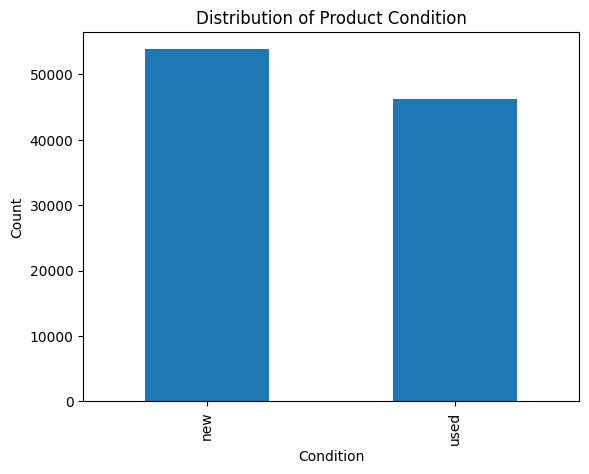

In [69]:
import matplotlib.pyplot as plt

df["condition"].value_counts().plot(kind="bar")
plt.title("Distribution of Product Condition")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

The condition distribution helps us understand whether the classification problem is balanced.

A reasonably balanced target is beneficial because:
- the model can learn both classes more effectively,
- evaluation metrics become easier to interpret,
- and the risk of bias toward the majority class is reduced.

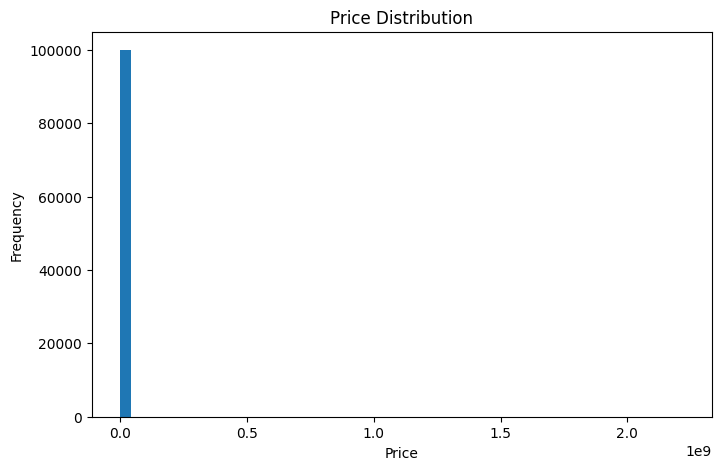

In [70]:
plt.figure(figsize=(8,5))
plt.hist(df["price"].dropna(), bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [71]:
df["price"].describe(percentiles=[0.5,0.75,0.9,0.95,0.99])

count    1.000000e+05
mean     5.252433e+04
std      8.623127e+06
min      8.400000e-01
50%      2.500000e+02
75%      8.000000e+02
90%      3.100000e+03
95%      7.500000e+03
99%      1.300000e+05
max      2.222222e+09
Name: price, dtype: float64

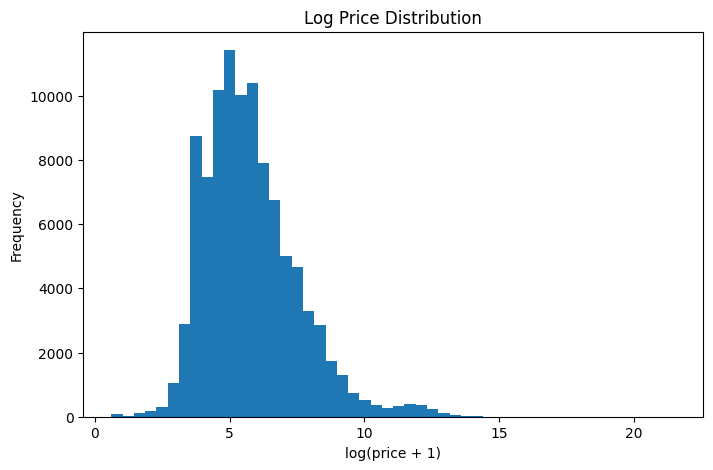

In [72]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["price"]), bins=50)
plt.title("Log Price Distribution")
plt.xlabel("log(price + 1)")
plt.ylabel("Frequency")
plt.show()

### Log-Transformed Price Distribution

The raw price distribution showed extreme skewness caused by very large outliers.  
To better understand the structure of the data, we applied a log transformation to the price variable using `log(price + 1)`.

After the transformation, the distribution becomes approximately bell-shaped. This suggests that the price variable follows a log-normal distribution, which is common in e-commerce marketplaces.

Most products appear within the range corresponding roughly to prices between 50 and 1000 units, while a smaller number of listings extend into higher price ranges.

Using the log-transformed price as the target variable can improve regression performance by stabilizing variance and reducing the impact of extreme values.

In [73]:
# Show example values for object columns
object_cols = df.select_dtypes(include="object").columns.tolist()

for col in object_cols:
    print(f"\nColumn: {col}")
    print(df[col].dropna().iloc[0] if df[col].dropna().shape[0] > 0 else "No non-null values")


Column: seller_address
{'country': {'name': 'Argentina', 'id': 'AR'}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}, 'city': {'name': 'San Cristóbal', 'id': 'TUxBQlNBTjkwNTZa'}}

Column: warranty
NUESTRA REPUTACION

Column: sub_status
[]

Column: condition
new

Column: deal_ids
[]

Column: shipping
{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'not_specified', 'dimensions': None}

Column: non_mercado_pago_payment_methods
[{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Acordar con el comprador', 'id': 'MLAWC', 'type': 'G'}, {'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}]

Column: variations
[]

Column: site_id
MLA

Column: listing_type_id
bronze

Column: attributes
[]

Column: buying_mode
buy_it_now

Column: tags
['dragged_bids_and_visits']

Column: listing_source


Column: parent_item_id
MLA6553902747

Column: coverage_areas
[]

Column: category_id
MLA126406

Column: descriptions
["{'id': 'MLA4

## Preliminary Column Removal Strategy

Based on the initial inspection, some columns appear to be weak candidates for the first modeling version.

We consider removing columns that fall into the following groups:

### 1. Extremely high missingness
Columns with very limited coverage are unlikely to contribute meaningful predictive value.

### 2. Pure identifiers or URLs
Variables such as item IDs, links, and image URLs are not inherently descriptive for modeling and may create noise.

### 3. Highly complex nested fields
Some variables contain lists or dictionaries that would require substantial feature extraction.  
For the first iteration, we may exclude the most complex ones and focus on more directly usable predictors.

This approach helps simplify the baseline model while preserving interpretability.

In [74]:
cols_to_drop_initial = [
    "differential_pricing",
    "subtitle",
    "catalog_product_id",
    "original_price",
    "official_store_id",
    "video_id",
    "id",
    "permalink",
    "thumbnail",
    "secure_thumbnail",
    "pictures",
    "descriptions",
    "coverage_areas",
    "deal_ids",
    "variations",
    "non_mercado_pago_payment_methods",
    "seller_id",
    "title"
]

df_eda = df.drop(columns=cols_to_drop_initial, errors="ignore")

print("Original shape:", df.shape)
print("After initial drop:", df_eda.shape)

Original shape: (100000, 45)
After initial drop: (100000, 27)


These columns are removed in the initial EDA version to simplify the analysis and reduce noise.

This does not mean they are permanently irrelevant.  
Some of them could be revisited in future iterations if we decide to engineer additional features from images, text, or nested metadata.

For now, the objective is to create a robust and interpretable baseline workflow.

In [75]:
df_eda.head(3)

,seller_address,warranty,sub_status,condition,base_price,shipping,site_id,listing_type_id,price,attributes,buying_mode,tags,listing_source,parent_item_id,category_id,last_updated,international_delivery_mode,accepts_mercadopago,currency_id,automatic_relist,date_created,stop_time,status,initial_quantity,start_time,sold_quantity,available_quantity
0,"{'country': {'name': 'Argentina', 'id': 'AR'}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}, 'city': {'name': 'San Cristóbal', 'id': 'TUxBQlNBTjkwNTZa'}}",None,[],new,80.0,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'not_specified', 'dimensions': None}",MLA,bronze,80.0,[],buy_it_now,[dragged_bids_and_visits],,MLA6553902747,MLA126406,2015-09-05T20:42:58.000Z,none,True,ARS,False,2015-09-05T20:42:53.000Z,2015-11-04 20:42:53,active,1,2015-09-05 20:42:53,0,1
1,"{'country': {'name': 'Argentina', 'id': 'AR'}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}, 'city': {'name': 'Buenos Aires', 'id': ''}}",NUESTRA REPUTACION,[],used,2650.0,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'me2', 'dimensions': None}",MLA,silver,2650.0,[],buy_it_now,[],,MLA7727150374,MLA10267,2015-09-26T18:08:34.000Z,none,True,ARS,False,2015-09-26T18:08:30.000Z,2015-11-25 18:08:30,active,1,2015-09-26 18:08:30,0,1
2,"{'country': {'name': 'Argentina', 'id': 'AR'}, 'state': {'name': 'Capital Federal', 'id': 'AR-C'}, 'city': {'name': 'Boedo', 'id': 'TUxBQkJPRTQ0OTRa'}}",None,[],used,60.0,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'me2', 'dimensions': None}",MLA,bronze,60.0,[],buy_it_now,[dragged_bids_and_visits],,MLA6561247998,MLA1227,2015-09-09T23:57:10.000Z,none,True,ARS,False,2015-09-09T23:57:07.000Z,2015-11-08 23:57:07,active,1,2015-09-09 23:57:07,0,1


## Feature Classification and Role Definition

Before proceeding with deeper preprocessing and modeling, it is important to classify the dataset variables according to their role in the analysis.

This step helps organize the dataset and clarify how each column may contribute to the predictive tasks.

In this project we are addressing two machine learning problems:

1. **Classification task**  
   Predict whether a product is **new or used**.

2. **Regression task**  
   Predict the **price** of a product.

To prepare the dataset properly, we divide the columns into several categories:

- **Target variables** – variables we aim to predict.
- **Numerical features** – quantitative variables that may help prediction.
- **Categorical features** – discrete variables describing product characteristics.
- **Text features** – descriptive text fields that may require special processing.
- **Temporal variables** – date-related fields that may contain time patterns.
- **Nested / complex variables** – dictionaries or lists that require feature extraction.
- **Identifier or URL fields** – variables with little predictive value that may be removed.

This classification allows us to design a structured preprocessing pipeline for both models.

In [76]:
df_eda.columns.tolist()

['seller_address',
 'warranty',
 'sub_status',
 'condition',
 'base_price',
 'shipping',
 'site_id',
 'listing_type_id',
 'price',
 'attributes',
 'buying_mode',
 'tags',
 'listing_source',
 'parent_item_id',
 'category_id',
 'last_updated',
 'international_delivery_mode',
 'accepts_mercadopago',
 'currency_id',
 'automatic_relist',
 'date_created',
 'stop_time',
 'status',
 'initial_quantity',
 'start_time',
 'sold_quantity',
 'available_quantity']

In [77]:
# Targets
target_classification = "condition"
target_regression = "price"


In [78]:
numerical_features = df_eda.select_dtypes(include=["int64","float64"]).columns.tolist()

# Remove targets
numerical_features = [c for c in numerical_features if c not in ["price"]]

numerical_features

['base_price', 'initial_quantity', 'sold_quantity', 'available_quantity']

In [79]:
categorical_features = df_eda.select_dtypes(include=["object"]).columns.tolist()

# remove obvious text columns
categorical_features

['seller_address',
 'warranty',
 'sub_status',
 'condition',
 'shipping',
 'site_id',
 'listing_type_id',
 'attributes',
 'buying_mode',
 'tags',
 'listing_source',
 'parent_item_id',
 'category_id',
 'last_updated',
 'international_delivery_mode',
 'currency_id',
 'date_created',
 'status']

### Exclusion of Text Features

The dataset contains textual information in the `title` field describing the product listing.

While product titles can provide valuable signals through Natural Language Processing (NLP) techniques, text processing introduces additional complexity such as:

- tokenization
- text normalization
- vectorization (e.g., TF-IDF or embeddings)
- high-dimensional feature spaces

Because the main objective of this project is to focus on **structured data modeling**, text-based features are excluded from the current analysis.

Future work could incorporate NLP techniques to extract additional predictive signals from product titles.

In [80]:
date_columns = ["date_created", "last_updated"]
complex_features = [
    "seller_address",
    "shipping",
    "attributes"
]



## Target-Focused Exploratory Data Analysis

After inspecting the dataset structure and cleaning the initial variables, we now explore the relationship between the key targets and other features.

This step aims to answer three important questions:

1. How is the **product condition** distributed in the dataset?
2. Do **new and used products have different price distributions**?
3. How does **price vary across product categories**?

Understanding these relationships helps validate the modeling strategy and ensures that the selected predictive tasks are meaningful.

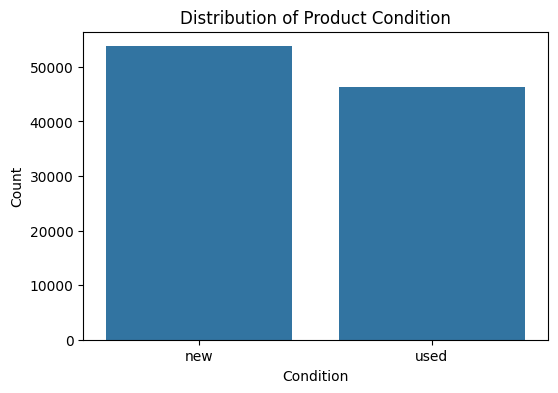

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="condition", data=df_eda)

plt.title("Distribution of Product Condition")
plt.xlabel("Condition")
plt.ylabel("Count")

plt.show()

### Product Condition Distribution

The `condition` variable represents whether a product is listed as **new** or **used**.

Understanding the class distribution is important because:

- balanced classes improve classification performance
- strong imbalance may require special handling
- evaluation metrics may need adjustment

This visualization provides a first look at the classification target.

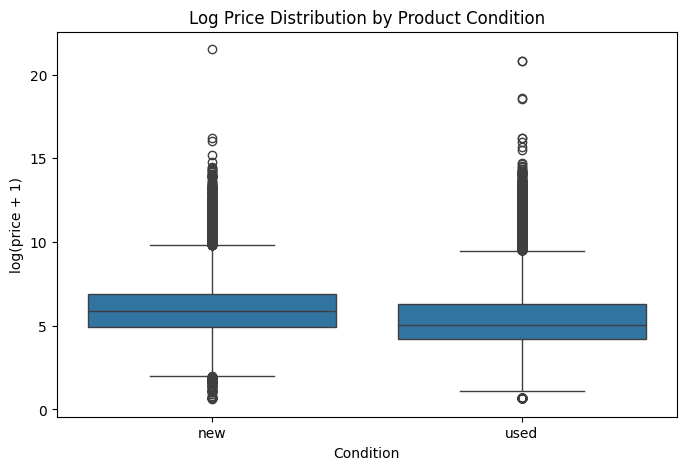

In [82]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="condition",
    y=np.log1p(df_eda["price"]),
    data=df_eda
)

plt.title("Log Price Distribution by Product Condition")
plt.xlabel("Condition")
plt.ylabel("log(price + 1)")

plt.show()

### Price vs Product Condition

This visualization compares the price distribution between **new** and **used** products.

The log transformation of price is used to reduce skewness and improve visualization clarity.

This analysis helps determine whether the product condition is associated with price differences.

If used items consistently show lower prices than new ones, this confirms that the condition variable carries strong economic information and justifies both:

- the classification task (detecting new vs used),
- the regression task (predicting price).

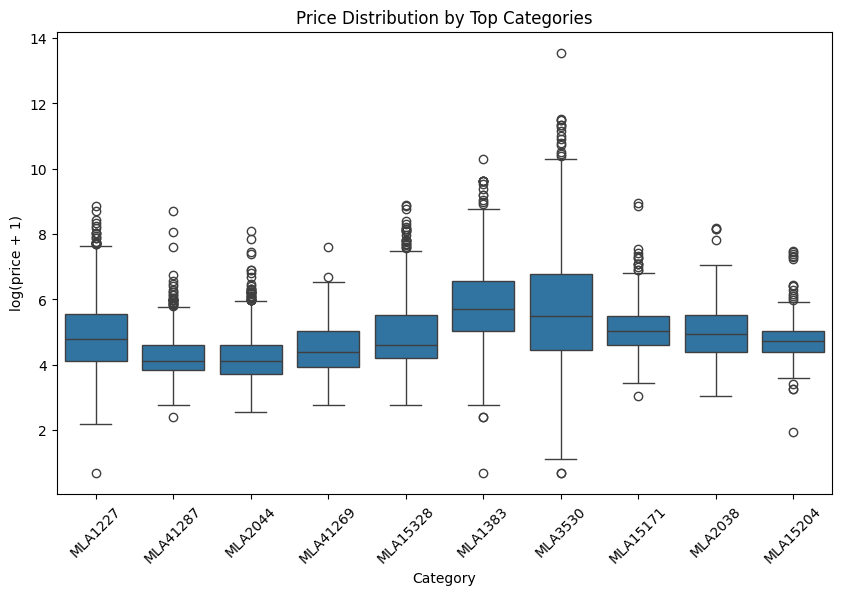

In [83]:
top_categories = df_eda["category_id"].value_counts().head(10).index

df_top_cat = df_eda[df_eda["category_id"].isin(top_categories)]

plt.figure(figsize=(10,6))

sns.boxplot(
    x="category_id",
    y=np.log1p(df_top_cat["price"]),
    data=df_top_cat
)

plt.xticks(rotation=45)

plt.title("Price Distribution by Top Categories")
plt.xlabel("Category")
plt.ylabel("log(price + 1)")

plt.show()

### Price Distribution by Category

Product categories often play a major role in price formation in marketplace environments.

For example:
- electronics tend to have higher prices
- accessories and small items tend to have lower prices

This visualization shows the price distribution across the most common product categories.

Significant differences between categories indicate that `category_id` is likely to be an important predictor in the regression model.

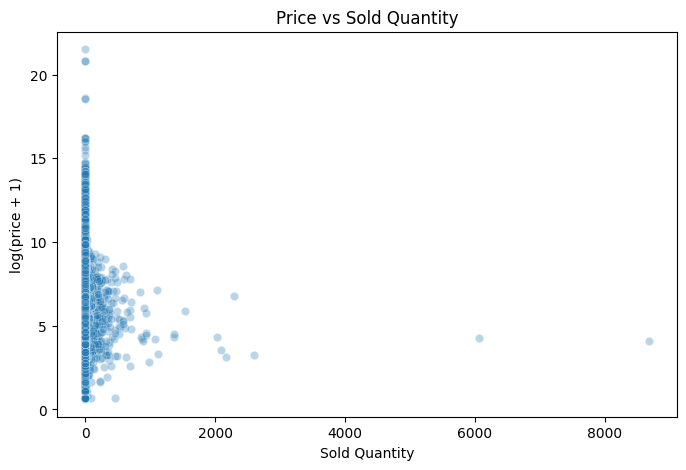

In [84]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="sold_quantity",
    y=np.log1p(df_eda["price"]),
    alpha=0.3,
    data=df_eda
)

plt.title("Price vs Sold Quantity")
plt.xlabel("Sold Quantity")
plt.ylabel("log(price + 1)")

plt.show()

### Relationship Between Price and Sales Volume

The scatter plot compares the log-transformed price with the number of units sold.

Most listings have very low sales volumes, with the majority of observations concentrated near zero sold units. This is typical in marketplace environments where many listings sell only a few items.

The relationship between price and sold quantity does not appear strongly linear. While some lower-priced items sell in larger quantities, the overall pattern suggests that sales volume alone is not a strong predictor of price.

This indicates that price formation is influenced by multiple factors, including product category, listing type, and product condition. Therefore, `sold_quantity` may still contribute useful information but should be combined with other features in the predictive models.


In [85]:
df_eda["seller_country"] = df_eda["seller_address"].apply(
    lambda x: x.get("country", {}).get("id") if isinstance(x, dict) else None
)

df_eda["seller_state"] = df_eda["seller_address"].apply(
    lambda x: x.get("state", {}).get("id") if isinstance(x, dict) else None
)

df_eda["seller_city"] = df_eda["seller_address"].apply(
    lambda x: x.get("city", {}).get("name") if isinstance(x, dict) else None
)

df_eda.drop(columns=["seller_address"], inplace=True)

In [86]:
df_eda["shipping_free"] = df_eda["shipping"].apply(
    lambda x: x.get("free_shipping") if isinstance(x, dict) else None
)

df_eda["shipping_pickup"] = df_eda["shipping"].apply(
    lambda x: x.get("local_pick_up") if isinstance(x, dict) else None
)

df_eda["shipping_mode"] = df_eda["shipping"].apply(
    lambda x: x.get("mode") if isinstance(x, dict) else None
)

df_eda.drop(columns=["shipping"], inplace=True)

In [87]:
df_eda["tag_count"] = df_eda["tags"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
df_eda.drop(columns=["tags"], inplace=True)

In [88]:
df_eda["attribute_count"] = df_eda["attributes"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

df_eda.drop(columns=["attributes"], inplace=True)

In [89]:
# waranty if has warranty or not
df_eda["has_warranty"] = df_eda["warranty"].notna().astype(int)
df_eda.drop(columns=["warranty"], inplace=True)

In [90]:
df_eda["date_created"] = pd.to_datetime(df_eda["date_created"])
df_eda["last_updated"] = pd.to_datetime(df_eda["last_updated"])

df_eda["listing_age_days"] = (
    df_eda["last_updated"] - df_eda["date_created"]
).dt.days

In [91]:
df_eda.head(3)

,sub_status,condition,base_price,site_id,listing_type_id,price,buying_mode,listing_source,parent_item_id,category_id,last_updated,international_delivery_mode,accepts_mercadopago,currency_id,automatic_relist,date_created,stop_time,status,initial_quantity,start_time,sold_quantity,available_quantity,seller_country,seller_state,seller_city,shipping_free,shipping_pickup,shipping_mode,tag_count,attribute_count,has_warranty,listing_age_days
0,[],new,80.0,MLA,bronze,80.0,buy_it_now,,MLA6553902747,MLA126406,2015-09-05 20:42:58+00:00,none,True,ARS,False,2015-09-05 20:42:53+00:00,2015-11-04 20:42:53,active,1,2015-09-05 20:42:53,0,1,AR,AR-C,San Cristóbal,False,True,not_specified,1,0,0,0
1,[],used,2650.0,MLA,silver,2650.0,buy_it_now,,MLA7727150374,MLA10267,2015-09-26 18:08:34+00:00,none,True,ARS,False,2015-09-26 18:08:30+00:00,2015-11-25 18:08:30,active,1,2015-09-26 18:08:30,0,1,AR,AR-C,Buenos Aires,False,True,me2,0,0,1,0
2,[],used,60.0,MLA,bronze,60.0,buy_it_now,,MLA6561247998,MLA1227,2015-09-09 23:57:10+00:00,none,True,ARS,False,2015-09-09 23:57:07+00:00,2015-11-08 23:57:07,active,1,2015-09-09 23:57:07,0,1,AR,AR-C,Boedo,False,True,me2,1,0,0,0


## Feature Distribution Analysis

After performing feature engineering and transforming nested variables, we analyze the distribution of the resulting features.

This step helps us:

- understand the range and variability of each feature
- detect constant or near-constant variables
- identify potential outliers
- evaluate whether features may contribute useful information to the predictive models

We start by examining numerical variables and categorical variables separately.

In [92]:
numerical_cols = df_eda.select_dtypes(include=["int64","float64"]).columns

df_eda[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
base_price,100000.0,52524.228548,8.623127e+06,0.84,90.0,250.0,800.0,2.222222e+09
price,100000.0,52524.328118,8.623127e+06,0.84,90.0,250.0,800.0,2.222222e+09
initial_quantity,100000.0,35.093370,4.210762e+02,1.00,1.0,1.0,2.0,9.999000e+03
sold_quantity,100000.0,2.396990,4.268508e+01,0.00,0.0,0.0,0.0,8.676000e+03
available_quantity,100000.0,34.842380,4.208084e+02,1.00,1.0,1.0,2.0,9.999000e+03
tag_count,100000.0,0.767160,4.595080e-01,0.00,1.0,1.0,1.0,2.000000e+00
attribute_count,100000.0,1.187550,7.543356e+00,0.00,0.0,0.0,0.0,8.100000e+01
has_warranty,100000.0,0.391040,4.879858e-01,0.00,0.0,0.0,1.0,1.000000e+00
listing_age_days,100000.0,7.123590,2.109776e+01,-1.00,0.0,0.0,6.0,8.750000e+02


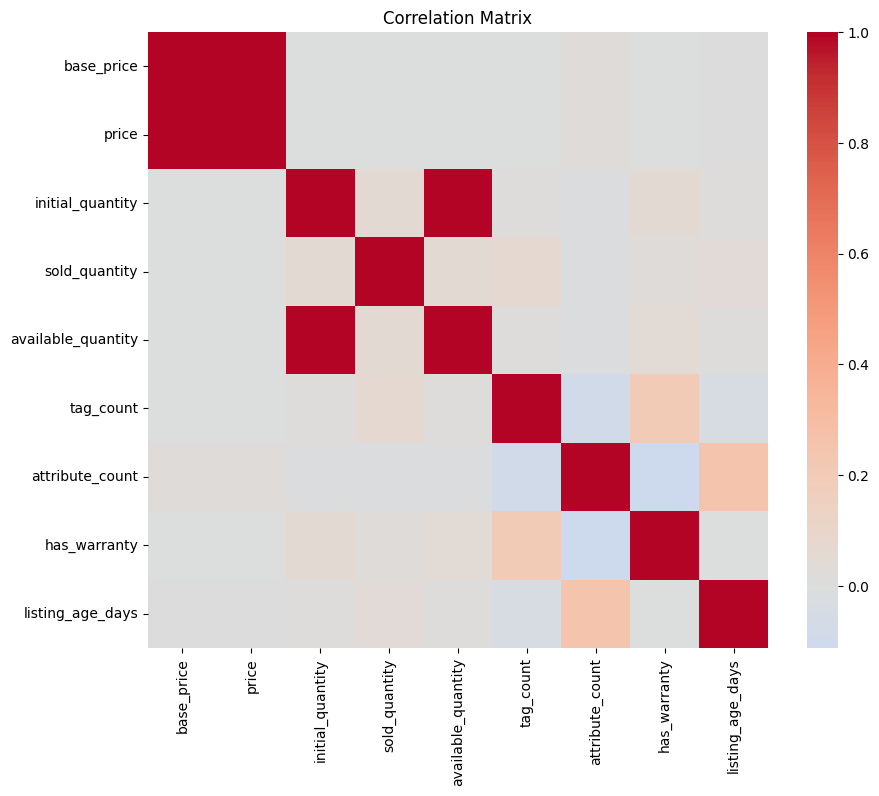

In [93]:
corr_matrix = df_eda[numerical_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

In [94]:
price_corr = corr_matrix["price"].sort_values(ascending=False)

price_corr

price                 1.000000
base_price            1.000000
attribute_count       0.020296
listing_age_days      0.001579
has_warranty          0.000545
sold_quantity        -0.000337
available_quantity   -0.000359
initial_quantity     -0.000362
tag_count            -0.000408
Name: price, dtype: float64

In [95]:
df_eda["condition_binary"] = df_eda["condition"].map({
    "new":1,
    "used":0
})

# recalcular columnas numéricas
numerical_cols = df_eda.select_dtypes(include=["int64","float64"]).columns

condition_corr = df_eda[numerical_cols].corr()["condition_binary"].sort_values(ascending=False)

condition_corr

condition_binary      1.000000
has_warranty          0.133516
listing_age_days      0.082655
initial_quantity      0.072873
available_quantity    0.072412
sold_quantity         0.050024
tag_count             0.008774
price                -0.000948
base_price           -0.000948
attribute_count      -0.087738
Name: condition_binary, dtype: float64

In [96]:
df_eda.drop(columns=["listing_source", "base_price","sub_status", "currency_id", "automatic_relist", "seller_country", "parent_item_id","seller_city", "site_id" ], inplace=True)

# Model Training and Evaluation

Linear Regretion

In [97]:
# Target (log transform)
y = np.log1p(df_eda["price"])



# Features
X = df_eda.drop(columns=["price", "condition_binary"])

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (80000, 22)
Test shape: (20000, 22)


In [99]:
numerical_features = X_train.select_dtypes(include=["int64","float64"]).columns
categorical_features = X_train.select_dtypes(include=["object","bool"]).columns

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: Index(['initial_quantity', 'sold_quantity', 'available_quantity', 'tag_count',
       'attribute_count', 'has_warranty', 'listing_age_days'],
      dtype='object')
Categorical: Index(['condition', 'listing_type_id', 'buying_mode', 'category_id',
       'international_delivery_mode', 'accepts_mercadopago', 'status',
       'seller_state', 'shipping_free', 'shipping_pickup', 'shipping_mode'],
      dtype='object')


In [100]:
df["category_id"].nunique()

10907

In [101]:
top_categories = X_train["category_id"].value_counts().nlargest(50).index

X_train["category_id"] = X_train["category_id"].where(
    X_train["category_id"].isin(top_categories),
    "other"
)

X_test["category_id"] = X_test["category_id"].where(
    X_test["category_id"].isin(top_categories),
    "other"
)

In [102]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded train shape: (80000, 103)
Encoded test shape: (20000, 103)


In [103]:
[c for c in X_train_encoded.columns if c.startswith("condition")]

['condition_used']

In [104]:
from sklearn.preprocessing import StandardScaler

datetime_cols = X_train_encoded.select_dtypes(include=["datetime64", "datetimetz"]).columns.tolist()
print("Dropping datetime columns:", datetime_cols)

X_train_encoded = X_train_encoded.drop(columns=datetime_cols, errors="ignore")
X_test_encoded = X_test_encoded.drop(columns=datetime_cols, errors="ignore")

scaler = StandardScaler()

X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train_encoded[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test_encoded[numerical_features])


Dropping datetime columns: ['last_updated', 'date_created', 'stop_time', 'start_time']


In [105]:
# Datetime columns already dropped in the scaling step above
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (80000, 99)
X_test_scaled shape: (20000, 99)


In [106]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [107]:
y_pred = model.predict(X_test_scaled)

In [108]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.066834210443972
RMSE: 1.3960020382650622
R²: 0.36774040480528714


In [109]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic = ElasticNet(max_iter=5000)

grid = GridSearchCV(
    elastic,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,ElasticNet(max_iter=5000)
,param_grid,"{'alpha': [0.001, 0.01, ...], 'l1_ratio': [0.1, 0.3, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.001


In [110]:
print("Best parameters:", grid.best_params_)

Best parameters: {'alpha': 0.001, 'l1_ratio': 0.1}


In [111]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

In [112]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.0685934845891285
RMSE: 1.3992773550739777
R²: 0.36477009423254014


The regression model produced an MAE of approximately 1.07 and an RMSE of 1.39 on the log-transformed price variable.

Since the model predicts the logarithm of the price, these error values correspond to multiplicative deviations in the original price scale.

Given the high variability of product prices across categories in marketplace data, this level of error is expected for a baseline linear regression model.

### Classification Model: Random Forest

To classify whether a product is **new** or **used**, we train a Random Forest classifier.

Random Forest is a tree-based ensemble model that combines multiple decision trees to improve predictive accuracy and reduce overfitting.

It is particularly well suited for tabular marketplace data because it can capture non-linear relationships and interactions between variables.

In [124]:
y_cls = df_eda["condition"]

X_cls = df_eda.drop(columns=["condition", "condition_binary", "price", "category_id"])

datetime_cols = X_cls.select_dtypes(include=["datetime", "datetimetz"]).columns

print("Removing datetime columns:", datetime_cols)

X_cls = X_cls.drop(columns=datetime_cols)

Removing datetime columns: Index(['last_updated', 'date_created', 'stop_time', 'start_time'], dtype='object')


In [125]:
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

In [126]:
numerical_features_cls = X_train_cls.select_dtypes(include=["int64","float64"]).columns
categorical_features_cls = X_train_cls.select_dtypes(include=["object","bool"]).columns
categorical_features_cls

Index(['listing_type_id', 'buying_mode', 'international_delivery_mode',
       'accepts_mercadopago', 'status', 'seller_state', 'shipping_free',
       'shipping_pickup', 'shipping_mode'],
      dtype='object')

In [127]:

# Excluir category_id del encoding (se deja como columna numérica/categórica sin dummies)
cols_to_encode_cls = [c for c in categorical_features_cls if c != "category_id"]

X_train_encoded_cls = pd.get_dummies(
    X_train_cls,
    columns=cols_to_encode_cls,
    drop_first=True
)

X_test_encoded_cls = pd.get_dummies(
    X_test_cls,
    columns=cols_to_encode_cls,
    drop_first=True
)

X_train_encoded_cls, X_test_encoded_cls = X_train_encoded_cls.align(
    X_test_encoded_cls,
    join="left",
    axis=1,
    fill_value=0
)


In [128]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [129]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

In [130]:
X_train_encoded_cls.head()

,initial_quantity,sold_quantity,available_quantity,tag_count,attribute_count,has_warranty,listing_age_days,listing_type_id_free,listing_type_id_gold,listing_type_id_gold_premium,listing_type_id_gold_pro,listing_type_id_gold_special,listing_type_id_silver,buying_mode_buy_it_now,buying_mode_classified,accepts_mercadopago_True,status_closed,status_not_yet_active,status_paused,seller_state_AR-A,seller_state_AR-B,seller_state_AR-C,seller_state_AR-D,seller_state_AR-E,seller_state_AR-F,seller_state_AR-G,seller_state_AR-H,seller_state_AR-J,seller_state_AR-K,seller_state_AR-L,seller_state_AR-M,seller_state_AR-N,seller_state_AR-P,seller_state_AR-Q,seller_state_AR-R,seller_state_AR-S,seller_state_AR-T,seller_state_AR-U,seller_state_AR-V,seller_state_AR-W,seller_state_AR-X,seller_state_AR-Y,seller_state_AR-Z,shipping_free_True,shipping_pickup_True,shipping_mode_me1,shipping_mode_me2,shipping_mode_not_specified
33818,1,0,1,1,0,1,11,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
96109,1,0,1,1,0,0,0,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True
55155,3,0,3,1,0,0,2,False,False,False,False,False,True,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
97470,5,0,5,0,0,0,25,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
57907,1,0,1,1,0,1,30,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [131]:
rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_encoded_cls, y_train_cls)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [132]:
print("Best parameters:", grid_rf.best_params_)

Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}


In [133]:
best_rf = grid_rf.best_estimator_

y_pred_cls = best_rf.predict(X_test_encoded_cls)

In [134]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test_cls, y_pred_cls)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls))

Accuracy: 0.8199

Classification Report:
              precision    recall  f1-score   support

         new       0.88      0.77      0.82     10752
        used       0.77      0.88      0.82      9248

    accuracy                           0.82     20000
   macro avg       0.82      0.82      0.82     20000
weighted avg       0.83      0.82      0.82     20000



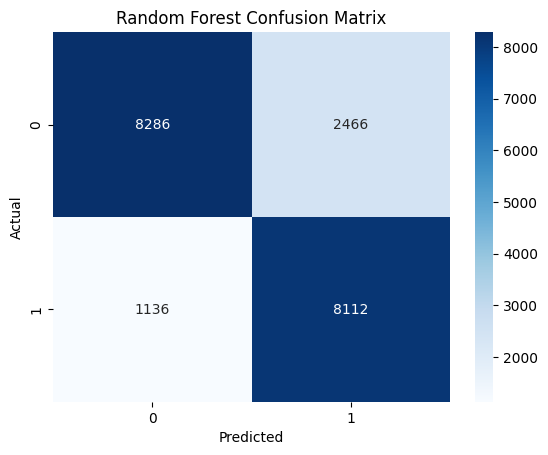

In [135]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cls, y_pred_cls)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [136]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train_encoded_cls.columns,
    "importance": best_rf.feature_importances_
})

feature_importance.sort_values("importance", ascending=False).head(15)

,feature,importance
7,listing_type_id_free,0.242377
2,available_quantity,0.225296
0,initial_quantity,0.201578
1,sold_quantity,0.090722
6,listing_age_days,0.049315
12,listing_type_id_silver,0.026505
3,tag_count,0.026243
4,attribute_count,0.025757
43,shipping_free_True,0.014913
5,has_warranty,0.013622


### Comparing Multiple Classification Models

To evaluate the robustness of the classification task, multiple machine learning algorithms were trained and compared.

Using the same training and testing datasets ensures that the comparison is fair and that differences in performance are due to the modeling approach rather than differences in data preparation.

The following models were evaluated:

- Logistic Regression
- Random Forest
- Gradient Boosting
- K-Nearest Neighbors

These models represent different learning paradigms and allow us to assess which approach performs best for detecting whether a product is new or used.

In [137]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_encoded_cls, y_train_cls)

y_pred_log = log_model.predict(X_test_encoded_cls)

In [138]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:",
      accuracy_score(y_test_cls, y_pred_log))

Logistic Regression Accuracy: 0.77575


In [139]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train_encoded_cls, y_train_cls)

y_pred_gb = gb_model.predict(X_test_encoded_cls)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test_cls, y_pred_gb))

Gradient Boosting Accuracy: 0.8115


In [144]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(X_train_encoded_cls, y_train_cls)

y_pred_knn = knn.predict(X_test_encoded_cls)

print("KNN Accuracy:",
      accuracy_score(y_test_cls, y_pred_knn))

KNN Accuracy: 0.80395


In [145]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test_cls, y_pred_log),
        accuracy_score(y_test_cls, y_pred_cls),
        accuracy_score(y_test_cls, y_pred_gb),
        accuracy_score(y_test_cls, y_pred_knn)
    ]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
1,Random Forest,0.81990
2,Gradient Boosting,0.81150
3,KNN,0.80395
0,Logistic Regression,0.77575


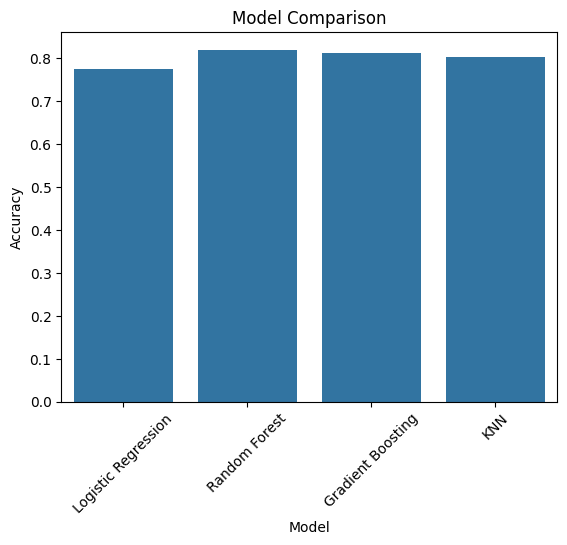

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=results, x="Model", y="Accuracy")

plt.title("Model Comparison")
plt.xticks(rotation=45)

plt.show()

### Model Comparison Results

Among all evaluated models, the Random Forest classifier achieved the highest accuracy (~82%), closely followed by Gradient Boosting (~81%).

This suggests that non-linear ensemble methods are more effective for this classification task compared to linear models such as Logistic Regression.

The relatively strong performance of KNN also indicates that the feature engineering and dimensionality reduction steps were effective in preserving meaningful structure in the data.

Overall, the results highlight the importance of using flexible models when dealing with complex marketplace datasets.

In [154]:
y_test_bin = y_test_cls.map({"new":0, "used":1})

In [155]:
from sklearn.metrics import roc_curve, auc

# Probabilidades (clase positiva = "new")
y_probs_rf = best_rf.predict_proba(X_test_encoded_cls)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test_bin, y_probs_rf)
auc_rf = auc(fpr_rf, tpr_rf)

print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.9100208794742621


In [156]:
y_probs_gb = gb_model.predict_proba(X_test_encoded_cls)[:,1]

fpr_gb, tpr_gb, _ = roc_curve(y_test_bin, y_probs_gb)
auc_gb = auc(fpr_gb, tpr_gb)

print("Gradient Boosting AUC:", auc_gb)

Gradient Boosting AUC: 0.9037082412526132


In [157]:
y_probs_log = log_model.predict_proba(X_test_encoded_cls)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test_bin, y_probs_log)
auc_log = auc(fpr_log, tpr_log)

print("Logistic Regression AUC:", auc_log)

Logistic Regression AUC: 0.8685291420393983


In [158]:
y_probs_knn = knn.predict_proba(X_test_encoded_cls)[:,1]

fpr_knn, tpr_knn, _ = roc_curve(y_test_bin, y_probs_knn)
auc_knn = auc(fpr_knn, tpr_knn)

print("KNN AUC:", auc_knn)

KNN AUC: 0.881726518732493


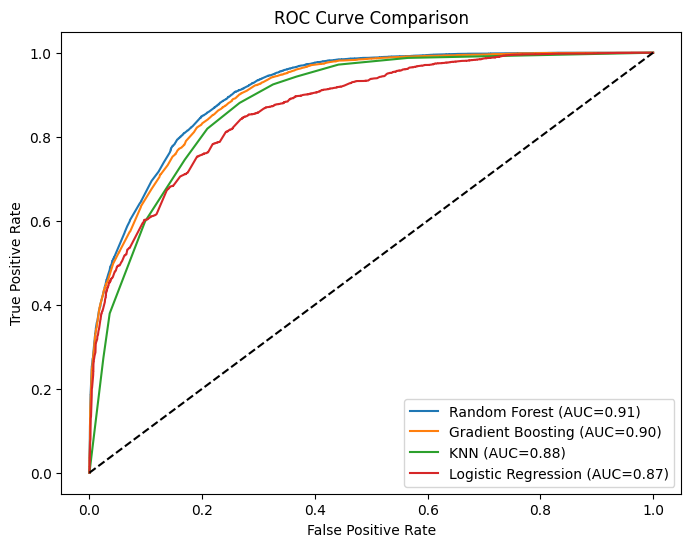

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={auc_gb:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.2f})")
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={auc_log:.2f})")

plt.plot([0,1], [0,1], "k--")  # línea random

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

### ROC Curve and AUC Analysis

The ROC curves show that all models achieve strong discriminative performance, with AUC values above 0.85.

Random Forest achieved the highest AUC (0.91), indicating the best ability to distinguish between new and used products across all classification thresholds.

Gradient Boosting performed similarly, confirming that ensemble methods are particularly effective for this task.

The results demonstrate that the engineered features capture meaningful signals related to product condition, enabling accurate classification.

In [160]:
y_probs_rf  = best_rf.predict_proba(X_test_encoded_cls)[:,1]
y_probs_gb  = gb_model.predict_proba(X_test_encoded_cls)[:,1]
y_probs_knn = knn.predict_proba(X_test_encoded_cls)[:,1]
y_probs_log = log_model.predict_proba(X_test_encoded_cls)[:,1]

In [161]:
from sklearn.metrics import precision_recall_curve, auc

precision_rf, recall_rf, _ = precision_recall_curve(y_test_bin, y_probs_rf)
precision_gb, recall_gb, _ = precision_recall_curve(y_test_bin, y_probs_gb)
precision_knn, recall_knn, _ = precision_recall_curve(y_test_bin, y_probs_knn)
precision_log, recall_log, _ = precision_recall_curve(y_test_bin, y_probs_log)

pr_auc_rf  = auc(recall_rf, precision_rf)
pr_auc_gb  = auc(recall_gb, precision_gb)
pr_auc_knn = auc(recall_knn, precision_knn)
pr_auc_log = auc(recall_log, precision_log)

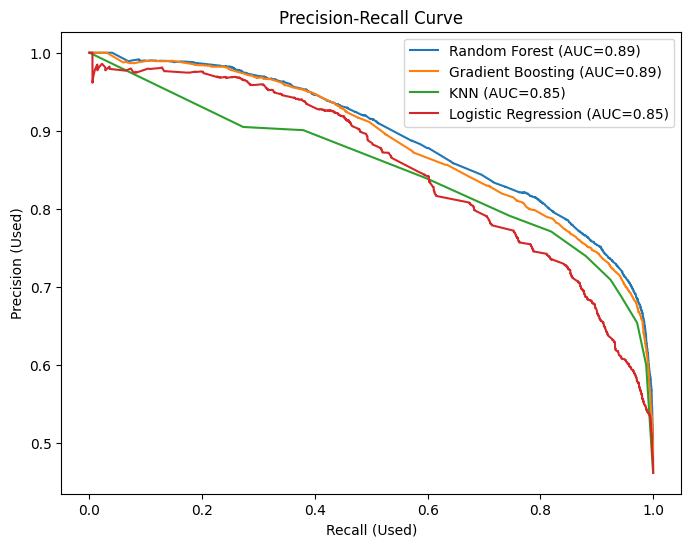

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(recall_rf, precision_rf, label=f"Random Forest (AUC={pr_auc_rf:.2f})")
plt.plot(recall_gb, precision_gb, label=f"Gradient Boosting (AUC={pr_auc_gb:.2f})")
plt.plot(recall_knn, precision_knn, label=f"KNN (AUC={pr_auc_knn:.2f})")
plt.plot(recall_log, precision_log, label=f"Logistic Regression (AUC={pr_auc_log:.2f})")

plt.xlabel("Recall (Used)")
plt.ylabel("Precision (Used)")
plt.title("Precision-Recall Curve")

plt.legend()
plt.show()

### Precision-Recall Analysis

The Precision-Recall curves were used to evaluate how well each model detects **used products**, which were treated as the positive class.

Random Forest achieved the highest Precision-Recall AUC, indicating the best balance between precision and recall when identifying used items.

This means that Random Forest is the most effective model for correctly identifying used products while minimizing false positives.

Gradient Boosting performed similarly, while Logistic Regression showed lower performance, reflecting its limited ability to capture complex patterns in the data.

In [163]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train_encoded_cls.columns,
    "importance": best_rf.feature_importances_
})

top_features = feature_importance.sort_values(
    "importance", ascending=False
).head(10)

top_features

,feature,importance
7,listing_type_id_free,0.242377
2,available_quantity,0.225296
0,initial_quantity,0.201578
1,sold_quantity,0.090722
6,listing_age_days,0.049315
12,listing_type_id_silver,0.026505
3,tag_count,0.026243
4,attribute_count,0.025757
43,shipping_free_True,0.014913
5,has_warranty,0.013622


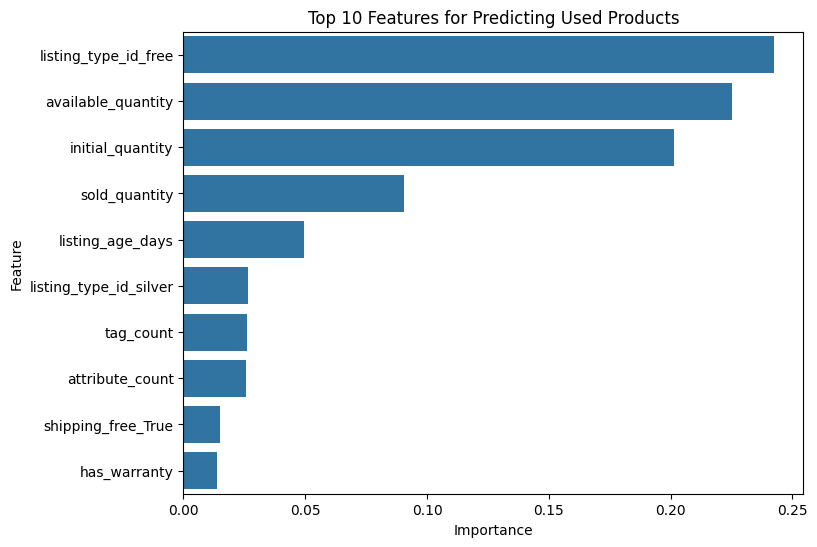

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 10 Features for Predicting Used Products")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Key Drivers of Used Product Classification

The feature importance analysis reveals that the model relies heavily on signals related to seller behavior and listing characteristics.

The most important factor is the listing type, where free listings are strongly associated with used products, while paid listings tend to correspond to new items.

Inventory-related variables such as available quantity and initial quantity also play a critical role, as used products are typically sold as single units, whereas new products are often associated with larger inventories.

Additionally, factors such as listing age, warranty availability, and shipping conditions further differentiate new and used products.

Overall, the model captures meaningful marketplace dynamics, distinguishing between casual sellers (more likely to sell used items) and professional sellers (more likely to sell new products).